# **Advertising Sales Impact** 📈

**Team 4:** Aylin, Mariana and Dina

**Goal:** To predict Sales based on TV, Radio, and Newspaper advertising budgets and compare two different models.

## **Library Imports**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, roc_curve, auc, classification_report, r2_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


## **Load and Clean Dataset**

In [ ]:
# Load the data
df = pd.read_csv("Advertising Budget and Sales.csv")

# Clean the data: remove the extra index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## **Basic EDA**

In [4]:
df.shape

(200, 4)

In [4]:
# Check for null values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.describe()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


**First impressions:**

* The dataset is relatively small, containing only 200 entries and 4 column (plus one old index that was removed)
* It only contains float items
* There are no NaN or null entries
* We can see there are minimums on Budget that are very low, nevertheless, the minimum on Sales is not zero, by this we can infer there are some cases where not as much money, or no money at all, was invested in certain areas
* By comparing the mean to the 50% (which is the median), we can tell how "skewed" the data is. In our case, for instance
  * TV and Radio: mean and median are very close. This tells us it holds a normal distribution.
  * Newspaper: mean is higher than the median. This indicates it has a right skew, we think it could likely be caused by a few "expensive" outliers

## **Relationships Visualization**

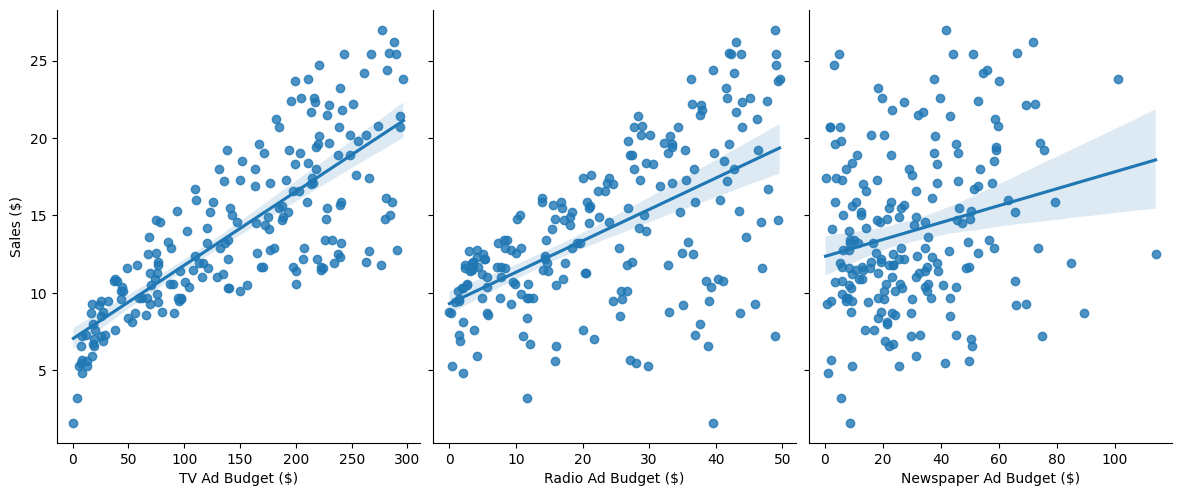

In [6]:
# grid of scatter plots with a linear regression line for each
sns.pairplot(df, x_vars=['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)'], 
             y_vars='Sales ($)', height=5, aspect=0.8, kind='reg')
plt.show()

Here, we can visualize the steeper the line and the more tightly the dots gather around it, the stronger the correlation to sales. We can see that TV shows the cleanest line in this dataset

## **Data Splitting (Train/Test Split)**

In [ ]:
# Define Features (X) and Target (y)
X = df[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]
y = df['Sales ($)']

# Split data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")



Training set size: 160
Testing set size: 40


## **Model 1 - Linear Regression**

### **K-FOLD cross validation**

Instead of a single train-test split, we implement 5-Fold Cross Validation for the Linear Regression model:

The Logic: The dataset is split into 5 equal "folds." The model is trained 5 times, each time using a different fold for testing and the other 4 for training.

The Goal: This provides a more reliable and stable estimate of the R-squared (R**2) score, proving that our results are consistent across the entire dataset and not just a result of a lucky split.

In [51]:
# --- Simple Linear Regression Training (Commented Out as requested) ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- 5-Fold Cross Validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_model = LinearRegression()

# Calculate R-squared scores using cross-validation
cv_scores = cross_val_score(lr_model, X, y, cv=kf, scoring='r2')

print(f"K-Fold R2 Scores: {cv_scores}")
print(f"Mean K-Fold R2 Score: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")

K-Fold R2 Scores: [0.89943802 0.81895573 0.93398674 0.90102145 0.86025006]
Mean K-Fold R2 Score: 0.8827
Standard Deviation of Accuracy: 0.0395


**Determine the Return on Investment (ROI)**

The ROI or coefficients tell us exactly how much sales increase for every $1 spent on a specific channel

In [53]:
#coeff_df = pd.DataFrame(lr_model.coef_, X.columns, columns=['Coefficient'])
#print(coeff_df)
# Fitting the model to access coefficients (Solves AttributeError)
lr_model.fit(X_train, y_train)

# Create ROI DataFrame
roi_df = pd.DataFrame(lr_model.coef_, X.columns, columns=['Return on $1 Spend'])
roi_df = roi_df.sort_values(by='Return on $1 Spend', ascending=False)

print("Marginal ROI per Advertising Channel:")
display(roi_df)

Marginal ROI per Advertising Channel:


,Return on $1 Spend
Radio Ad Budget ($),0.189195
TV Ad Budget ($),0.044730
Newspaper Ad Budget ($),0.002761


TV has a coefficient of 0.04, it means that for every $100 spent on TV, we can expect around 5 units of sales

The highest number we see is the Radio, this is our most "efficient" channel.

**Model Evaluation (RMSE)**

In order to prove how accurate our model is. We use the R-squared ($R^2$), which tells us how much of the "Sales" variance is explained by our budget.

In [43]:
predictions = lr_model.predict(X_test)
print(f"R-squared: {r2_score(y_test, predictions)}")

R-squared: 0.899438024100912


Our $R^2$ of 0.89 means the ad budgets explain 90% of the sales, which is excellent.

## **Model 2 - Random Forest**

In [44]:
# 1. Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Feature Importance
importances = pd.DataFrame(rf_model.feature_importances_, X.columns, columns=['Importance'])
print(importances)

# 3. Evaluation
rf_preds = rf_model.predict(X_test)
print(f"\nRandom Forest R-squared: {r2_score(y_test, rf_preds):.4f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")

                         Importance
TV Ad Budget ($)           0.624791
Radio Ad Budget ($)        0.362282
Newspaper Ad Budget ($)    0.012927

Random Forest R-squared: 0.9814
Random Forest RMSE: 0.7658


## **Save the Model (The "Pickle" Step)**

In [54]:
import joblib

# Save both models as .pkl files to use them in the Streamlit app
joblib.dump(lr_model, 'linear_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

print("Success! Both 'linear_model.pkl' and 'random_forest_model.pkl' are saved.")

Success! Both 'linear_model.pkl' and 'random_forest_model.pkl' are saved.
